✅ Corrected L1 Total: 5.5507267887656075
✅ Corrected L1 Mean: 0.0037004845258437383


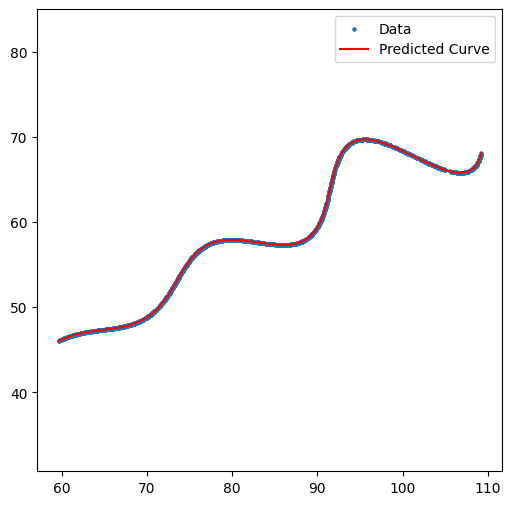

In [4]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

# Load CSV
data = pd.read_csv("xy_data.csv")
x_true, y_true = data['x'].values, data['y'].values

# Parameters
theta = 0.5236177
M = 0.0300005039
X = 55.00333601

# Generate dense curve points
t = np.linspace(6, 60, 5000)
x_pred = t*np.cos(theta) - np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta) + X
y_pred = 42 + t*np.sin(theta) + np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(theta)

# Find nearest distances from each data point to predicted curve
tree = cKDTree(np.c_[x_pred, y_pred])
distances, _ = tree.query(np.c_[x_true, y_true])

L1_total = np.sum(distances)
L1_mean = np.mean(distances)

print("✅ Corrected L1 Total:", L1_total)
print("✅ Corrected L1 Mean:", L1_mean)

plt.figure(figsize=(6,6))
plt.scatter(x_true, y_true, s=5, label="Data")
plt.plot(x_pred, y_pred, 'r', label="Predicted Curve")
plt.axis('equal')
plt.legend()
plt.show()
